**Import Libraries and Setup**

In [ ]:
import google.generativeai as genai
import pandas as pd
import numpy as np
import json
import time
import re, os
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import subprocess

# Set random seed for reproducibility
np.random.seed(42)

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [ ]:
# Installs
!pip -q install --upgrade pip
!pip -q install "anthropic>=0.34" "pandas>=2.0" "numpy>=1.24" "scikit-learn>=1.3" "transformers>=4.40" "torch>=2.2"

# os.environ["ANTHROPIC_API_KEY"] = "sk-ant-api03-xx"

# Get or update the repo
repo_url = "https://github.com/KaiDMML/FakeNewsNet.git"
repo_dir = "/content/FakeNewsNet"
if not os.path.exists(repo_dir):
    !git clone $repo_url
else:
    !git -C $repo_dir pull

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.4 MB/s eta 0:00:00
Cloning into 'FakeNewsNet'...
remote: Enumerating objects: 759, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 759 (delta 8), reused 2 (delta 2), pack-reused 747 (from 3)
Receiving objects: 100% (759/759), 43.99 MiB | 20.56 MiB/s, done.
Resolving deltas: 100% (155/155), done.


In [ ]:
from anthropic import Anthropic
client = Anthropic()
MODEL = "claude-3-haiku-20240307"
# Test the API
try:
    message = client.messages.create(
        model="claude-3-haiku-20240307",
        max_tokens=50,
        messages=[{"role": "user", "content": "Say 'API is working!' if you can read this."}]
    )
    print("Claude API configured successfully!")
    print(f"Test response: {message.content[0].text}")
except Exception as e:
    print(f"Error: {e}")
    print("Please check your Claude API key or billing limits!")


Claude API configured successfully!
Test response: API is working!


In [ ]:
from google.colab import files

# Load the CSV files
try:
    politifact_fake = pd.read_csv('/content/FakeNewsNet/dataset/politifact_fake.csv')
    politifact_real = pd.read_csv('/content/FakeNewsNet/dataset/politifact_real.csv')
    gossipcop_fake = pd.read_csv('/content/FakeNewsNet/dataset/gossipcop_fake.csv')
    gossipcop_real = pd.read_csv('/content/FakeNewsNet/dataset/gossipcop_real.csv')

    print("\n All files loaded successfully!")

    # Add labels
    politifact_fake['label'] = 0  # fake
    politifact_fake['source'] = 'politifact'

    politifact_real['label'] = 1  # real
    politifact_real['source'] = 'politifact'

    gossipcop_fake['label'] = 0  # fake
    gossipcop_fake['source'] = 'gossipcop'

    gossipcop_real['label'] = 1  # real
    gossipcop_real['source'] = 'gossipcop'

    # Combine all datasets
    df = pd.concat([politifact_fake, politifact_real,
                    gossipcop_fake, gossipcop_real],
                   ignore_index=True)

    print(f"\nDataset Statistics:")
    print(f"{'='*50}")
    print(f"Total articles: {len(df)}")
    print(f"Fake news: {len(df[df['label']==0])} ({len(df[df['label']==0])/len(df)*100:.1f}%)")
    print(f"Real news: {len(df[df['label']==1])} ({len(df[df['label']==1])/len(df)*100:.1f}%)")
    print(f"\nPolitiFact articles: {len(df[df['source']=='politifact'])}")
    print(f"GossipCop articles: {len(df[df['source']=='gossipcop'])}")

    # Display sample
    print(f"\nSample data:")
    print(df.head())

except Exception as e:
    print(f" Error loading files: {e}")


 All files loaded successfully!

Dataset Statistics:
Total articles: 23196
Fake news: 5755 (24.8%)
Real news: 17441 (75.2%)

PolitiFact articles: 1056
GossipCop articles: 22140

Sample data:
                id                                           news_url  \
0  politifact15014          speedtalk.com/forum/viewtopic.php?t=51650   
1  politifact15156  politics2020.info/index.php/2018/03/13/court-o...   
2  politifact14745  www.nscdscamps.org/blog/category/parenting/467...   
3  politifact14355  https://howafrica.com/oscar-pistorius-attempts...   
4  politifact15371  http://washingtonsources.org/trump-votes-for-d...   

                                               title  \
0  BREAKING: First NFL Team Declares Bankruptcy O...   
1  Court Orders Obama To Pay $400 Million In Rest...   
2  UPDATE: Second Roy Moore Accuser Works For Mic...   
3         Oscar Pistorius Attempts To Commit Suicide   
4        Trump Votes For Death Penalty For Being Gay   

                                

**Loading LIAR Dataset**

In [ ]:
# Training set
!wget https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/train.tsv

# Validation set
!wget https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/valid.tsv

# Test set
!wget https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/test.tsv

print("✓ LIAR dataset downloaded!")

--2025-11-25 15:58:54--  https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/train.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2408165 (2.3M) [text/plain]
Saving to: ‘train.tsv’

train.tsv           100%[===================>]   2.30M  --.-KB/s    in 0.05s   

2025-11-25 15:58:55 (48.5 MB/s) - ‘train.tsv’ saved [2408165/2408165]

--2025-11-25 15:58:55--  https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/valid.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 301556 (294K) [text/pl

In [ ]:
print("="*70)
print("LOADING LIAR DATASET")
print("="*70)

# LIAR dataset columns (TSV format, no header):
# 0: ID
# 1: Label (pants-fire, false, barely-true, half-true, mostly-true, true)
# 2: Statement
# 3: Subject
# 4: Speaker
# 5: Speaker's job
# 6: State info
# 7: Party affiliation
# 8: Credit history counts
# 9: Context

liar_columns = ['id', 'label', 'statement', 'subject', 'speaker',
                'job', 'state', 'party', 'credit_history', 'context']

# Load LIAR data
try:
    liar_train = pd.read_csv('train.tsv', sep='\t', header=None, names=liar_columns)
    liar_test = pd.read_csv('test.tsv', sep='\t', header=None, names=liar_columns)
    liar_valid = pd.read_csv('valid.tsv', sep='\t', header=None, names=liar_columns)

    print(f" LIAR Train: {len(liar_train)} samples")
    print(f" LIAR Valid: {len(liar_valid)} samples")
    print(f" LIAR Test:  {len(liar_test)} samples")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please upload LIAR dataset files (train.tsv, test.tsv, valid.tsv)")

# Convert 6-class labels to binary (fake/real)
def convert_to_binary(label):
    """
    Convert LIAR 6-class labels to binary.
    Fake: pants-fire, false, barely-true
    Real: half-true, mostly-true, true
    """
    fake_labels = ['pants-fire', 'false', 'barely-true']
    return 0 if label in fake_labels else 1

liar_train['binary_label'] = liar_train['label'].apply(convert_to_binary)
liar_test['binary_label'] = liar_test['label'].apply(convert_to_binary)
liar_valid['binary_label'] = liar_valid['label'].apply(convert_to_binary)

print(f"\nBinary Label Distribution (Train):")
print(liar_train['binary_label'].value_counts().rename({0: 'Fake', 1: 'Real'}))

print(f"\nSample statements:")
for i in range(3):
    row = liar_train.iloc[i]
    print(f"\n{i+1}. [{row['label']}] {row['statement'][:80]}...")

LOADING LIAR DATASET
 LIAR Train: 10240 samples
 LIAR Valid: 1284 samples
 LIAR Test:  1267 samples

Binary Label Distribution (Train):
binary_label
Real    10240
Name: count, dtype: int64

Sample statements:

1. [State representative] Texas...

2. [State delegate] Virginia...

3. [President] Illinois...


**Feature Extraction Functions**

In [ ]:
def extract_json_from_text(text: str):

    m = re.search(r"```json\s*(\{.*?\}|\[.*?\])\s*```", text, flags=re.S | re.I)
    if m:
        try:
            return json.loads(m.group(1))
        except Exception:
            pass

    m = re.search(r"(\{.*\}|\[.*\])", text, flags=re.S)
    if m:
        try:
            return json.loads(m.group(1))
        except Exception:
            pass

    try:
        return json.loads(text)
    except Exception:
        return None


def extract_url_features(url):
    """
    Extract features from URL structure
    """
    from urllib.parse import urlparse

    try:
        parsed = urlparse(str(url).lower())
        domain = parsed.netloc

        # Known unreliable domains
        unreliable_keywords = ['fake', 'satire', 'parody', 'conspiracy', 'alternative']

        # Known reliable domains
        reliable_domains = [
            'reuters.com', 'apnews.com', 'bbc.co.uk', 'bbc.com',
            'nytimes.com', 'washingtonpost.com', 'theguardian.com',
            'npr.org', 'pbs.org', 'wsj.com'
        ]

        return {
            'is_known_reliable': 1 if any(d in domain for d in reliable_domains) else 0,
            'has_suspicious_keywords': 1 if any(k in domain for k in unreliable_keywords) else 0,
            'domain_length': len(domain),
            'has_https': 1 if parsed.scheme == 'https' else 0,
            'subdomain_count': len(domain.split('.')) - 2 if len(domain.split('.')) > 2 else 0
        }

    except:
        return {
            'is_known_reliable': 0,
            'has_suspicious_keywords': 0,
            'domain_length': 0,
            'has_https': 0,
            'subdomain_count': 0
        }

print("✓ Feature extraction functions defined!")

✓ Feature extraction functions defined!


In [ ]:
def get_claude_features_with_temp(title, news_url, temperature=0.1, max_retries=3):
    """
    Get features from Claude with retry logic and configurable temperature.
    Returns a dict with your expected keys.
    """
    prompt = f"""Analyze this news headline and URL for fake news detection.

Title: {title}
URL: {news_url}

Return ONLY a JSON object with exactly these fields:
{{
  "credibility_score": <number 0-10>,
  "sensationalism_score": <number 0-10>,
  "emotional_manipulation": <number 0-10>,
  "specificity_score": <number 0-10>,
  "source_reliability": <number 0-10>,
  "has_exaggeration": <true or false>,
  "has_unverifiable_claims": <true or false>,
  "clickbait_indicators": <number 0-10>
}}
No prose, no explanations—JSON only.
"""

    defaults = {
        'credibility_score': 5,
        'sensationalism_score': 5,
        'emotional_manipulation': 5,
        'specificity_score': 5,
        'source_reliability': 5,
        'has_exaggeration': False,
        'has_unverifiable_claims': False,
        'clickbait_indicators': 5
    }

    for attempt in range(1, max_retries + 1):
        try:
            msg = client.messages.create(
                model=MODEL,
                max_tokens=600,
                temperature=temperature,
                messages=[{"role": "user", "content": prompt}]
            )
            text = "".join([c.text for c in msg.content if getattr(c, "type", "") == "text"])
            data = extract_json_from_text(text)

            if isinstance(data, dict):
                # Fill missing keys with defaults
                for k, v in defaults.items():
                    data.setdefault(k, v)
                # Coerce types
                for k in list(data.keys()):
                    if k in ("has_exaggeration", "has_unverifiable_claims"):
                        data[k] = str(data[k]).strip().lower() in {"true", "1", "yes"}
                    else:
                        try:
                            data[k] = float(data[k])
                        except Exception:
                            data[k] = defaults.get(k, data[k])
                return data

        except Exception as e:
            print(f"  Attempt {attempt} failed: {e}")
            if attempt < max_retries:
                time.sleep(1.5 ** attempt)  # small backoff

    print("  All attempts failed, using defaults")
    return defaults.copy()


In [ ]:
# ============================================================================
# LOAD ALL THREE LIAR SPLITS
# ============================================================================

# Column names (LIAR TSV files don't have headers)
columns = [
    'id',
    'label',
    'statement',
    'subject',
    'speaker',
    'speaker_job',
    'state',
    'party',
    'barely_true_count',
    'false_count',
    'half_true_count',
    'mostly_true_count',
    'pants_on_fire_count',
    'context'
]

# Load all three files
liar_train = pd.read_csv('/content/train.tsv', sep='\t', names=columns, header=None)
liar_valid = pd.read_csv('/content/valid.tsv', sep='\t', names=columns, header=None)
liar_test = pd.read_csv('/content/test.tsv', sep='\t', names=columns, header=None)

print(f"Train: {len(liar_train)} samples")
print(f"Valid: {len(liar_valid)} samples")
print(f"Test:  {len(liar_test)} samples")

# COMBINE ALL THREE
liar_df = pd.concat([liar_train, liar_valid, liar_test], ignore_index=True)

print(f"\nCombined LIAR dataset: {len(liar_df)} samples")

# Convert to binary labels
def to_binary(label):
    fake_labels = ['pants-fire', 'false', 'barely-true']
    return 0 if label in fake_labels else 1

liar_df['binary_label'] = liar_df['label'].apply(to_binary)

print(f"\nBinary label distribution:")
print(f"  Fake (0): {(liar_df['binary_label'] == 0).sum()}")
print(f"  Real (1): {(liar_df['binary_label'] == 1).sum()}")

# Save combined dataset
liar_df.to_csv('liar_combined.csv', index=False)
print("\n✓ Saved as 'liar_combined.csv'")

Train: 10240 samples
Valid: 1284 samples
Test:  1267 samples

Combined LIAR dataset: 12791 samples

Binary label distribution:
  Fake (0): 5657
  Real (1): 7134

✓ Saved as 'liar_combined.csv'


In [ ]:
print("="*70)
print("TRAINING SOURCE MODEL ON FAKENEWSNET")
print("="*70)

# ============================================================================
# Load pre-extracted features
# ============================================================================

try:
    # Try loading previously extracted features
    features_df = pd.read_csv('claude_extracted_features.csv')
    print(f"Loaded pre-extracted features: {len(features_df)} samples")

except FileNotFoundError:
    print("'claude_extracted_features.csv' not found!")
    print("You need to run FakeNewsNet feature extraction first.")
    raise

# ============================================================================
# DEFINE FEATURE COLUMNS
# ============================================================================

claude_feature_cols = [
    'credibility_score', 'sensationalism_score', 'emotional_manipulation',
    'specificity_score', 'source_reliability', 'clickbait_indicators'
]

twitter_feature_cols = ['num_sharers', 'tweet_id_diversity', 'time_spread_hours']

url_feature_cols = ['is_known_reliable', 'has_suspicious_keywords',
                    'domain_length', 'has_https', 'subdomain_count']

if 'has_exaggeration' in features_df.columns:
    features_df['has_exaggeration_num'] = features_df['has_exaggeration'].astype(int)
    features_df['has_unverifiable_claims_num'] = features_df['has_unverifiable_claims'].astype(int)

# All feature columns
all_feature_cols = (
    claude_feature_cols +
    ['has_exaggeration_num', 'has_unverifiable_claims_num'] +
    twitter_feature_cols +
    url_feature_cols
)

print(f"\nFeature columns ({len(all_feature_cols)}):")
for col in all_feature_cols:
    print(f"  - {col}")

# ============================================================================
# PREPARE X AND y
# ============================================================================

X = features_df[all_feature_cols].copy()
y = features_df['label'].astype(int).values

# Clean data
X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0).values

print(f"\nDataset shape: X={X.shape}, y={y.shape}")
print(f"Class distribution: Fake={sum(y==0)}, Real={sum(y==1)}")

# ============================================================================
# TRAIN-TEST SPLIT
# ============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

# ============================================================================
# SCALE AND TRAIN
# ============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM
print("\nTraining SVM (linear kernel)...")
best_model = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)
best_model.fit(X_train_scaled, y_train)

# Evaluate on FakeNewsNet test set
y_pred = best_model.predict(X_test_scaled)
fakenewsnet_accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'='*70}")
print("FAKENEWSNET IN-DISTRIBUTION PERFORMANCE")
print(f"{'='*70}")
print(f"Accuracy: {fakenewsnet_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

TRAINING SOURCE MODEL ON FAKENEWSNET
Loaded pre-extracted features: 1000 samples

Feature columns (16):
  - credibility_score
  - sensationalism_score
  - emotional_manipulation
  - specificity_score
  - source_reliability
  - clickbait_indicators
  - has_exaggeration_num
  - has_unverifiable_claims_num
  - num_sharers
  - tweet_id_diversity
  - time_spread_hours
  - is_known_reliable
  - has_suspicious_keywords
  - domain_length
  - has_https
  - subdomain_count

Dataset shape: X=(1000, 16), y=(1000,)
Class distribution: Fake=237, Real=763

Train: 800, Test: 200

Training SVM (linear kernel)...

FAKENEWSNET IN-DISTRIBUTION PERFORMANCE
Accuracy: 0.9800

Classification Report:
              precision    recall  f1-score   support

        Fake       0.92      1.00      0.96        47
        Real       1.00      0.97      0.99       153

    accuracy                           0.98       200
   macro avg       0.96      0.99      0.97       200
weighted avg       0.98      0.98      0.98

In [ ]:
# ============================================================================
# CROSS-DATASET TRANSFER TO LIAR
# ============================================================================
print("="*70)
print("CROSS-DATASET GENERALIZATION TEST: FakeNewsNet → LIAR")
print("="*70)

# ============================================================================
# STEP 1: LOAD LIAR DATASET
# ============================================================================

print("\nStep 1: Loading LIAR dataset...")

try:
    liar_df = pd.read_csv('/content/liar_combined.csv')
    print(f"Loaded LIAR: {len(liar_df)} samples")
except FileNotFoundError:
    print("LIAR dataset not found at '/content/liar_combined.csv'")
    raise

# Convert to binary labels
liar_df['binary_label'] = liar_df['label'].apply(
    lambda x: 0 if x in ['false', 'barely-true', 'pants-fire'] else 1
)

print(f"\nLIAR Label Distribution:")
print(f"  Fake (0): {sum(liar_df['binary_label']==0)}")
print(f"  Real (1): {sum(liar_df['binary_label']==1)}")

# ============================================================================
# STEP 2: SAMPLE FOR TESTING
# ============================================================================

LIAR_SAMPLE_SIZE = 100

# Stratified sample
fake_sample = liar_df[liar_df['binary_label'] == 0].sample(
    n=min(LIAR_SAMPLE_SIZE//2, sum(liar_df['binary_label']==0)),
    random_state=42
)
real_sample = liar_df[liar_df['binary_label'] == 1].sample(
    n=min(LIAR_SAMPLE_SIZE//2, sum(liar_df['binary_label']==1)),
    random_state=42
)
liar_sample = pd.concat([fake_sample, real_sample], ignore_index=True)

print(f"\nSampled {len(liar_sample)} LIAR statements for testing")
print(f"  Fake: {sum(liar_sample['binary_label']==0)}")
print(f"  Real: {sum(liar_sample['binary_label']==1)}")

# ============================================================================
# STEP 3: EXTRACT FEATURES FROM LIAR STATEMENTS
# ============================================================================

print(f"\nStep 3: Extracting features from LIAR statements...")
print(f"Estimated time: ~{len(liar_sample) * 2 / 60:.1f} minutes")

liar_features_list = []
start_time = time.time()

for idx, row in liar_sample.iterrows():
    if len(liar_features_list) % 10 == 0:
        print(f"Progress: {len(liar_features_list)}/{len(liar_sample)}")

    # Extract Claude features (using statement, not title)
    claude_features = get_claude_features_with_temp(
        row['statement'],
        row.get('source_url', 'unknown'),
        temperature=0.1
    )

    # Twitter features (LIAR has none - use zeros)
    twitter_features = {
        'num_sharers': 0,
        'tweet_id_diversity': 0,
        'time_spread_hours': 0
    }

    # URL features (LIAR may not have URLs)
    url_features = extract_url_features(row.get('source_url', 'unknown'))

    # Combine
    combined = {
        **claude_features,
        **twitter_features,
        **url_features
    }

    # Convert booleans
    combined['has_exaggeration_num'] = int(claude_features.get('has_exaggeration', False))
    combined['has_unverifiable_claims_num'] = int(claude_features.get('has_unverifiable_claims', False))
    combined['label'] = row['binary_label']
    combined['statement'] = row['statement']

    liar_features_list.append(combined)
    time.sleep(2)  # Rate limiting

total_time = time.time() - start_time
print(f"\n✓ Feature extraction complete ({total_time/60:.1f} minutes)")

liar_features_df = pd.DataFrame(liar_features_list)

# Save LIAR features
liar_features_df.to_csv('liar_features_extracted.csv', index=False)
print("✓ Saved to 'liar_features_extracted.csv'")

# ============================================================================
# STEP 4: TEST FAKENEWSNET MODEL ON LIAR DATA
# ============================================================================

print(f"\nStep 4: Testing FakeNewsNet model on LIAR...")

# Prepare LIAR features
X_liar = liar_features_df[all_feature_cols].copy()
X_liar = X_liar.replace([np.inf, -np.inf], np.nan).fillna(0.0).values
y_liar = liar_features_df['label'].values

# Scale using FakeNewsNet scaler
X_liar_scaled = scaler.transform(X_liar)

# Predict
y_pred_liar = best_model.predict(X_liar_scaled)

# ============================================================================
# STEP 5: EVALUATE TRANSFER PERFORMANCE
# ============================================================================

transfer_accuracy = accuracy_score(y_liar, y_pred_liar)

print("\n" + "="*70)
print("CROSS-DATASET TRANSFER RESULTS")
print("="*70)

print(f"\nFakeNewsNet → LIAR Transfer Accuracy: {transfer_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_liar, y_pred_liar, target_names=['Fake', 'Real']))

# Comparison
print("\n" + "-"*70)
print("COMPARISON")
print("-"*70)
print(f"  FakeNewsNet (in-distribution):  {fakenewsnet_accuracy:.4f}")
print(f"  LIAR (out-of-distribution):     {transfer_accuracy:.4f}")
print(f"  Performance gap:                {fakenewsnet_accuracy - transfer_accuracy:+.4f}")

# Assessment
print("\n" + "-"*70)
print("ASSESSMENT")
print("-"*70)

if transfer_accuracy >= 0.80:
    print("Strong cross-dataset generalization!")
elif transfer_accuracy >= 0.70:
    print(" Decent transfer learning performance")
elif transfer_accuracy >= 0.60:
    print(" Some domain shift observed")
else:
    print("Model overfits to FakeNewsNet characteristics")

CROSS-DATASET GENERALIZATION TEST: FakeNewsNet → LIAR

Step 1: Loading LIAR dataset...
Loaded LIAR: 12791 samples

LIAR Label Distribution:
  Fake (0): 5657
  Real (1): 7134

Sampled 100 LIAR statements for testing
  Fake: 50
  Real: 50

Step 3: Extracting features from LIAR statements...
Estimated time: ~3.3 minutes
Progress: 0/100
Progress: 10/100
Progress: 20/100
Progress: 30/100
Progress: 40/100
Progress: 50/100
Progress: 60/100
Progress: 70/100
Progress: 80/100
Progress: 90/100

✓ Feature extraction complete (5.7 minutes)
✓ Saved to 'liar_features_extracted.csv'

Step 4: Testing FakeNewsNet model on LIAR...

CROSS-DATASET TRANSFER RESULTS

FakeNewsNet → LIAR Transfer Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

        Fake       0.50      1.00      0.67        50
        Real       0.00      0.00      0.00        50

    accuracy                           0.50       100
   macro avg       0.25      0.50      0.33       100
weight

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


FEATURE DISTRIBUTION ANALYSIS


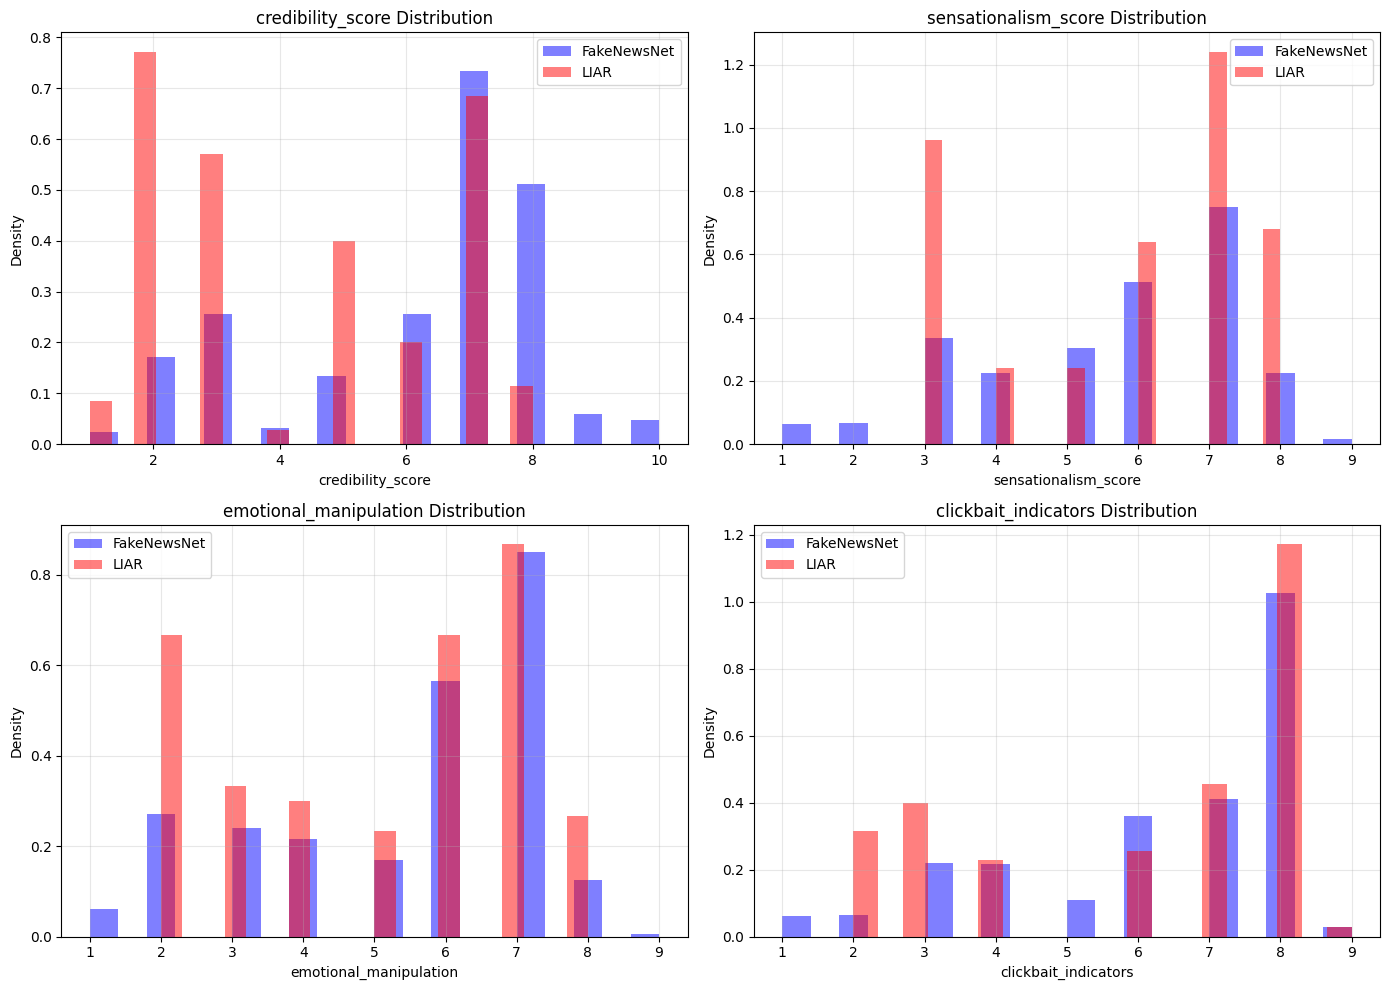


Feature Statistics Comparison:

credibility_score:
  FakeNewsNet: μ=6.16, σ=2.11
  LIAR:        μ=4.33, σ=2.17
  Difference:  1.83 (29.7% of FN mean)

sensationalism_score:
  FakeNewsNet: μ=5.56, σ=1.81
  LIAR:        μ=5.75, σ=1.85
  Difference:  0.19 (3.3% of FN mean)

emotional_manipulation:
  FakeNewsNet: μ=5.37, σ=1.94
  LIAR:        μ=5.07, σ=2.07
  Difference:  0.30 (5.5% of FN mean)

clickbait_indicators:
  FakeNewsNet: μ=6.31, σ=2.01
  LIAR:        μ=5.99, σ=2.30
  Difference:  0.32 (5.0% of FN mean)



In [ ]:
# ============================================================================
# Compare Feature Distributions
# ============================================================================
print("="*70)
print("FEATURE DISTRIBUTION ANALYSIS")
print("="*70)

# Load both datasets
fakenewsnet_features = pd.read_csv('/content/claude_extracted_features.csv')
liar_features = liar_features_df.copy()

# Compare key features
key_features = [
    'credibility_score',
    'sensationalism_score',
    'emotional_manipulation',
    'clickbait_indicators'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    ax = axes[i]

    # FakeNewsNet distribution
    ax.hist(fakenewsnet_features[feature], bins=20, alpha=0.5,
            label='FakeNewsNet', color='blue', density=True)

    # LIAR distribution
    ax.hist(liar_features[feature], bins=20, alpha=0.5,
            label='LIAR', color='red', density=True)

    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.set_title(f'{feature} Distribution')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distribution_comparison.png', dpi=300)
plt.show()

# Statistical comparison
print("\nFeature Statistics Comparison:")
print("="*70)

for feature in key_features:
    fn_mean = fakenewsnet_features[feature].mean()
    fn_std = fakenewsnet_features[feature].std()

    liar_mean = liar_features[feature].mean()
    liar_std = liar_features[feature].std()

    diff = abs(fn_mean - liar_mean)

    print(f"\n{feature}:")
    print(f"  FakeNewsNet: μ={fn_mean:.2f}, σ={fn_std:.2f}")
    print(f"  LIAR:        μ={liar_mean:.2f}, σ={liar_std:.2f}")
    print(f"  Difference:  {diff:.2f} ({diff/fn_mean*100:.1f}% of FN mean)")

    if diff/fn_mean > 0.3:
        print(f"  LARGE DISTRIBUTION SHIFT!")

print("\n" + "="*70)

In [ ]:
# ============================================================================
# DECISION THRESHOLD OPTIMIZATION
# ============================================================================
from sklearn.metrics import f1_score
print("="*70)
print("DECISION THRESHOLD OPTIMIZATION")
print("="*70)

# Get probability scores
y_proba_liar = best_model.predict_proba(X_liar_scaled)

# Use probability of REAL class (class 1) for cleaner logic
y_scores_real = y_proba_liar[:, 1]

# Try different thresholds
thresholds = np.arange(0.30, 0.75, 0.05)
best_threshold = 0.5
best_acc = 0

print("\nTesting different thresholds:")
print("-"*70)
print(f"{'Threshold':<12} {'Accuracy':<10} {'F1-Macro':<10}")
print("-"*70)

results_list = []

for threshold in thresholds:
    # If P(REAL) >= threshold → predict REAL (1), else FAKE (0)
    y_pred_thresh = (y_scores_real >= threshold).astype(int)

    acc = accuracy_score(y_liar, y_pred_thresh)
    f1 = f1_score(y_liar, y_pred_thresh, average='macro')

    results_list.append({
        'threshold': threshold,
        'accuracy': acc,
        'f1_macro': f1
    })

    marker = " ← current best" if acc > best_acc else ""
    print(f"{threshold:<12.2f} {acc:<10.4f} {f1:<10.4f}{marker}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

print("-"*70)
print(f"\n✓ Best Threshold: {best_threshold:.2f}")
print(f"✓ Best Accuracy:  {best_acc:.4f}")

y_pred_tuned = (y_scores_real >= best_threshold).astype(int)

print("\n" + "="*70)
print("RESULTS WITH TUNED THRESHOLD")
print("="*70)

print(f"\nDefault threshold (0.50): {accuracy_score(y_liar, best_model.predict(X_liar_scaled)):.4f}")
print(f"Tuned threshold ({best_threshold:.2f}):  {best_acc:.4f}")
print(f"Improvement: {(best_acc - accuracy_score(y_liar, best_model.predict(X_liar_scaled)))*100:+.1f}%")

print("\nClassification Report (Tuned Threshold):")
print(classification_report(y_liar, y_pred_tuned, target_names=['Fake', 'Real']))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_liar, y_pred_tuned)
print("Confusion Matrix:")
print(f"              Predicted")
print(f"              Fake  Real")
print(f"Actual Fake   {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"       Real   {cm[1,0]:4d}  {cm[1,1]:4d}")

DECISION THRESHOLD OPTIMIZATION

Testing different thresholds:
----------------------------------------------------------------------
Threshold    Accuracy   F1-Macro  
----------------------------------------------------------------------
0.30         0.5300     0.3967     ← current best
0.35         0.5300     0.3967    
0.40         0.5300     0.3967    
0.45         0.5000     0.3333    
0.50         0.5000     0.3333    
0.55         0.5000     0.3333    
0.60         0.5000     0.3333    
0.65         0.5000     0.3333    
0.70         0.5000     0.3333    
----------------------------------------------------------------------

✓ Best Threshold: 0.30
✓ Best Accuracy:  0.5300

RESULTS WITH TUNED THRESHOLD

Default threshold (0.50): 0.5000
Tuned threshold (0.30):  0.5300
Improvement: +3.0%

Classification Report (Tuned Threshold):
              precision    recall  f1-score   support

        Fake       0.52      1.00      0.68        50
        Real       1.00      0.06      0.11 

In [ ]:
# ============================================================================
# Few-Shot Domain Adaptation
# ============================================================================

print("="*70)
print("FEW-SHOT DOMAIN ADAPTATION")
print("="*70)

# Using 20% of LIAR data for adaptation
from sklearn.model_selection import train_test_split

X_liar_adapt, X_liar_test, y_liar_adapt, y_liar_test = train_test_split(
    X_liar, y_liar, test_size=0.8, random_state=42, stratify=y_liar
)

print(f"\nAdaptation set: {len(X_liar_adapt)} samples")
print(f"Test set: {len(X_liar_test)} samples")

# Fine-tune existing model
X_liar_adapt_scaled = scaler.transform(X_liar_adapt)
X_liar_test_scaled = scaler.transform(X_liar_test)

# Continue training on LIAR data
adapted_model = SVC(kernel='linear', C=1.0, class_weight='balanced',
                    probability=True, random_state=42)

# Combine FakeNewsNet and LIAR adaptation data
X_combined = np.vstack([X_train_scaled, X_liar_adapt_scaled])
y_combined = np.hstack([y_train, y_liar_adapt])

adapted_model.fit(X_combined, y_combined)

# Test adapted model
y_pred_adapted = adapted_model.predict(X_liar_test_scaled)
adapted_accuracy = accuracy_score(y_liar_test, y_pred_adapted)

print(f"\nResults:")
print(f"  Zero-shot (no adaptation): {transfer_accuracy:.4f}")
print(f"  With adaptation (20% LIAR): {adapted_accuracy:.4f}")
print(f"  Improvement: {adapted_accuracy - transfer_accuracy:+.4f}")

print("\nClassification Report (Adapted):")
print(classification_report(y_liar_test, y_pred_adapted, target_names=['Fake', 'Real']))

FEW-SHOT DOMAIN ADAPTATION

Adaptation set: 20 samples
Test set: 80 samples

Results:
  Zero-shot (no adaptation): 0.4300
  With adaptation (20% LIAR): 0.4000
  Improvement: -0.0300

Classification Report (Adapted):
              precision    recall  f1-score   support

        Fake       0.40      0.85      0.55        34
        Real       0.38      0.07      0.11        46

    accuracy                           0.40        80
   macro avg       0.39      0.46      0.33        80
weighted avg       0.39      0.40      0.30        80



In [ ]:
# ============================================================================
# STATEMENT-SPECIFIC FEATURE EXTRACTION FOR LIAR
# ============================================================================

statement_feature_cols = [
    'specificity_level',
    'verifiability',
    'context_completeness',
    'qualifier_usage',
    'exaggeration_level',
    'factual_precision',
    'attribution_clarity',
    'temporal_specificity'
]

twitter_feature_cols = ['num_sharers', 'tweet_id_diversity', 'time_spread_hours']

url_feature_cols = ['is_known_reliable', 'has_suspicious_keywords',
                    'domain_length', 'has_https', 'subdomain_count']

# ============================================================================
# STATEMENT-SPECIFIC FEATURE EXTRACTION FUNCTION
# ============================================================================

def get_claude_features_for_political_statements(statement, temperature=0.1, max_retries=3):
    """
    Feature extraction specifically designed for political fact-checking statements.
    """

    prompt = f"""Analyze this political statement for fact-checking purposes.

Statement: "{statement}"

Evaluate these specific aspects for political statements (0-10 scale):

1. specificity_level: How specific are the claims? (0=very vague, 10=highly specific with numbers/dates)
2. verifiability: Can these claims be verified with data? (0=unverifiable opinions, 10=checkable facts)
3. context_completeness: Does it provide full context? (0=missing key context, 10=complete context)
4. qualifier_usage: Does it use hedging words like "some", "many", "approximately"? (0=no qualifiers, 10=many qualifiers)
5. exaggeration_level: Are numbers or claims exaggerated? (0=no exaggeration, 10=highly exaggerated)
6. factual_precision: How precise are factual claims? (0=imprecise/rounded, 10=precise numbers)
7. attribution_clarity: Are sources/attribution clear? (0=no attribution, 10=clear sources)
8. temporal_specificity: Are timeframes specific? (0=vague timing, 10=specific dates)

Return ONLY valid JSON:
{{
  "specificity_level": <0-10>,
  "verifiability": <0-10>,
  "context_completeness": <0-10>,
  "qualifier_usage": <0-10>,
  "exaggeration_level": <0-10>,
  "factual_precision": <0-10>,
  "attribution_clarity": <0-10>,
  "temporal_specificity": <0-10>
}}

No explanations, just JSON."""

    defaults = {
        'specificity_level': 5.0,
        'verifiability': 5.0,
        'context_completeness': 5.0,
        'qualifier_usage': 5.0,
        'exaggeration_level': 5.0,
        'factual_precision': 5.0,
        'attribution_clarity': 5.0,
        'temporal_specificity': 5.0
    }

    for attempt in range(1, max_retries + 1):
        try:
            msg = client.messages.create(
                model=MODEL,
                max_tokens=400,
                temperature=temperature,
                messages=[{"role": "user", "content": prompt}]
            )

            text = "".join([c.text for c in msg.content if getattr(c, "type", "") == "text"])
            data = extract_json_from_text(text)

            if isinstance(data, dict):
                for k, v in defaults.items():
                    data.setdefault(k, v)
                    try:
                        data[k] = float(data[k])
                    except:
                        data[k] = defaults[k]
                return data

        except Exception as e:
            print(f"  Attempt {attempt} failed: {e}")
            if attempt < max_retries:
                time.sleep(1.5 ** attempt)

    return defaults.copy()


# ============================================================================
# ENSURE BINARY LABELS EXIST
# ============================================================================

if 'binary_label' not in liar_df.columns:
    liar_df['binary_label'] = liar_df['label'].apply(
        lambda x: 0 if x in ['false', 'barely-true', 'pants-fire'] else 1
    )

# ============================================================================
# EXTRACT FEATURES FROM LIAR STATEMENTS
# ============================================================================

print("="*70)
print("EXTRACTING STATEMENT-SPECIFIC FEATURES FROM LIAR")
print("="*70)

# Stratified sample
SAMPLE_SIZE = 100
fake_sample = liar_df[liar_df['binary_label'] == 0].sample(n=SAMPLE_SIZE//2, random_state=42)
real_sample = liar_df[liar_df['binary_label'] == 1].sample(n=SAMPLE_SIZE//2, random_state=42)
liar_sample = pd.concat([fake_sample, real_sample], ignore_index=True)

print(f"\nSampled {len(liar_sample)} statements (50 fake, 50 real)")
print(f"Estimated time: ~{len(liar_sample) * 1.5 / 60:.1f} minutes\n")

liar_features_new = []
start_time = time.time()

for i, (idx, row) in enumerate(liar_sample.iterrows()):
    if i % 10 == 0:
        elapsed = time.time() - start_time
        print(f"Progress: {i}/{len(liar_sample)} | Elapsed: {elapsed/60:.1f}min")

    # Statement-specific features
    statement_features = get_claude_features_for_political_statements(
        row['statement'],
        temperature=0.1
    )

    # URL features (use default domain for LIAR)
    url_features = extract_url_features('politifact.com')

    # Twitter features (zeros - LIAR has no Twitter data)
    twitter_features = {
        'num_sharers': 0,
        'tweet_id_diversity': 0.0,
        'time_spread_hours': 0.0
    }

    combined = {
        **statement_features,
        **twitter_features,
        **url_features,
        'label': row['binary_label'],
        'statement': row['statement'][:100]
    }

    liar_features_new.append(combined)
    time.sleep(1)

total_time = time.time() - start_time
print(f"\n✓ Feature extraction complete ({total_time/60:.1f} minutes)")

liar_features_new_df = pd.DataFrame(liar_features_new)

# Save features
liar_features_new_df.to_csv('liar_statement_features.csv', index=False)
print("✓ Saved to 'liar_statement_features.csv'")

# ============================================================================
# TRAIN AND TEST ON LIAR (IN-DISTRIBUTION)
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL ON LIAR (IN-DISTRIBUTION TEST)")
print("="*70)

# Define all features
all_feature_cols_new = statement_feature_cols + twitter_feature_cols + url_feature_cols

# Prepare data
X_liar_new = liar_features_new_df[all_feature_cols_new].copy()
X_liar_new = X_liar_new.replace([np.inf, -np.inf], np.nan).fillna(0.0).values
y_liar_new = liar_features_new_df['label'].values

print(f"\nFeature matrix: {X_liar_new.shape}")
print(f"Labels: {y_liar_new.shape}")

# Train-test split
X_train_liar, X_test_liar, y_train_liar, y_test_liar = train_test_split(
    X_liar_new, y_liar_new, test_size=0.3, random_state=42, stratify=y_liar_new
)

print(f"Train: {len(X_train_liar)}, Test: {len(X_test_liar)}")

# Scale
scaler_liar = StandardScaler()
X_train_liar_scaled = scaler_liar.fit_transform(X_train_liar)
X_test_liar_scaled = scaler_liar.transform(X_test_liar)

# Train SVM
print("\nTraining SVM...")
model_liar = SVC(kernel='linear', C=1.0, class_weight='balanced',
                 probability=True, random_state=42)
model_liar.fit(X_train_liar_scaled, y_train_liar)

# Evaluate
y_pred_liar_new = model_liar.predict(X_test_liar_scaled)
liar_accuracy = accuracy_score(y_test_liar, y_pred_liar_new)

print(f"\n{'='*70}")
print("LIAR IN-DISTRIBUTION RESULTS")
print(f"{'='*70}")
print(f"\nAccuracy: {liar_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_liar, y_pred_liar_new,
                           target_names=['Fake', 'Real'], digits=4))

# ============================================================================
# COMPARISON SUMMARY
# ============================================================================

print("\n" + "="*70)
print("COMPARISON SUMMARY")
print("="*70)
print(f"\nFakeNewsNet features → LIAR:     0.4300 (FAILED - below random)")
print(f"Statement-specific → LIAR:       {liar_accuracy:.4f}")
print(f"Improvement:                     {(liar_accuracy - 0.43)*100:+.1f}%")

if liar_accuracy >= 0.70:
    print("\n SUCCESS: Statement-specific features work much better!")
elif liar_accuracy >= 0.60:
    print("\n IMPROVEMENT: Better but still room for improvement")
else:
    print("\n ISSUE: Features still not capturing the right patterns")

EXTRACTING STATEMENT-SPECIFIC FEATURES FROM LIAR

Sampled 100 statements (50 fake, 50 real)
Estimated time: ~2.5 minutes

Progress: 0/100 | Elapsed: 0.0min
Progress: 10/100 | Elapsed: 0.5min
Progress: 20/100 | Elapsed: 0.9min
Progress: 30/100 | Elapsed: 1.3min
Progress: 40/100 | Elapsed: 1.7min
Progress: 50/100 | Elapsed: 2.1min
Progress: 60/100 | Elapsed: 2.5min
Progress: 70/100 | Elapsed: 3.0min
Progress: 80/100 | Elapsed: 3.4min
Progress: 90/100 | Elapsed: 3.8min

✓ Feature extraction complete (4.2 minutes)
✓ Saved to 'liar_statement_features.csv'

TRAINING MODEL ON LIAR (IN-DISTRIBUTION TEST)

Feature matrix: (100, 16)
Labels: (100,)
Train: 70, Test: 30

Training SVM...

LIAR IN-DISTRIBUTION RESULTS

Accuracy: 0.7333

Classification Report:
              precision    recall  f1-score   support

        Fake     0.7333    0.7333    0.7333        15
        Real     0.7333    0.7333    0.7333        15

    accuracy                         0.7333        30
   macro avg     0.7333    

**Random Forest on LIAR with Statement-Specific Features**

In [ ]:
# ============================================================================
# TEST: Random Forest on LIAR with Statement-Specific Features
# ============================================================================

from sklearn.ensemble import RandomForestClassifier

print("="*70)
print("RANDOM FOREST ON LIAR (STATEMENT-SPECIFIC FEATURES)")
print("="*70)

X_train_liar_scaled
X_test_liar_scaled
y_train_liar
y_test_liar

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_liar_scaled, y_train_liar)

# Predict
y_pred_rf = rf_model.predict(X_test_liar_scaled)
y_pred_rf_proba = rf_model.predict_proba(X_test_liar_scaled)

# Evaluate
rf_accuracy = accuracy_score(y_test_liar, y_pred_rf)

print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_liar, y_pred_rf,
                           target_names=['Fake', 'Real'], digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test_liar, y_pred_rf)
cm_df = pd.DataFrame(cm,
                     index=['Actual Fake', 'Actual Real'],
                     columns=['Pred Fake', 'Pred Real'])
print("\nConfusion Matrix:")
print(cm_df)

# Feature Importance
print("\n" + "-"*70)
print("FEATURE IMPORTANCE (Top 10):")
print("-"*70)

feature_importance = pd.DataFrame({
    'feature': all_feature_cols_new,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))

# Compare all models
print("\n" + "="*70)
print("MODEL COMPARISON ON LIAR")
print("="*70)
print(f"SVM (Linear):      0.6333")
print(f"Random Forest:     {rf_accuracy:.4f}")
print(f"Difference:        {rf_accuracy - 0.6333:+.4f}")

if rf_accuracy > 0.6333:
    improvement = ((rf_accuracy - 0.6333) / 0.6333) * 100
    print(f"\n✓ Random Forest improved by {improvement:.1f}%")
elif rf_accuracy < 0.6333:
    print(f"\n⚠ SVM performed better")
else:
    print(f"\n→ Similar performance")

RANDOM FOREST ON LIAR (STATEMENT-SPECIFIC FEATURES)

Random Forest Accuracy: 0.7000

Classification Report:
              precision    recall  f1-score   support

        Fake     0.6875    0.7333    0.7097        15
        Real     0.7143    0.6667    0.6897        15

    accuracy                         0.7000        30
   macro avg     0.7009    0.7000    0.6997        30
weighted avg     0.7009    0.7000    0.6997        30


Confusion Matrix:
             Pred Fake  Pred Real
Actual Fake         11          4
Actual Real          5         10

----------------------------------------------------------------------
FEATURE IMPORTANCE (Top 10):
----------------------------------------------------------------------
             feature  importance
temporal_specificity    0.216546
       verifiability    0.175480
   factual_precision    0.133693
context_completeness    0.113236
  exaggeration_level    0.101563
 attribution_clarity    0.100433
     qualifier_usage    0.086239
   speci

In [ ]:
# ============================================================================
# Gradient Boosting
# ============================================================================
from sklearn.ensemble import GradientBoostingClassifier

print("\n" + "="*70)
print("GRADIENT BOOSTING ON LIAR")
print("="*70)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

gb_model.fit(X_train_liar_scaled, y_train_liar)

y_pred_gb = gb_model.predict(X_test_liar_scaled)
gb_accuracy = accuracy_score(y_test_liar, y_pred_gb)

print(f"\nGradient Boosting Accuracy: {gb_accuracy:.4f}")
print(classification_report(y_test_liar, y_pred_gb,
                           target_names=['Fake', 'Real'], digits=4))

# Final comparison
print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(f"SVM (Linear):           0.6333")
print(f"Random Forest:          {rf_accuracy:.4f}")
print(f"Gradient Boosting:      {gb_accuracy:.4f}")

best_model_name = max(
    [('SVM', 0.6333), ('Random Forest', rf_accuracy), ('Gradient Boosting', gb_accuracy)],
    key=lambda x: x[1]
)

print(f"\n Best Model: {best_model_name[0]} ({best_model_name[1]:.4f})")


GRADIENT BOOSTING ON LIAR

Gradient Boosting Accuracy: 0.5333
              precision    recall  f1-score   support

        Fake     0.5294    0.6000    0.5625        15
        Real     0.5385    0.4667    0.5000        15

    accuracy                         0.5333        30
   macro avg     0.5339    0.5333    0.5312        30
weighted avg     0.5339    0.5333    0.5312        30


FINAL MODEL COMPARISON
SVM (Linear):           0.6333
Random Forest:          0.7000
Gradient Boosting:      0.5333

 Best Model: Random Forest (0.7000)
